# Lab 2: IMU Data Collection and Analysis

This notebook covers all the data collection and analysis tasks for Lab 2:
1. Setup and connect to Artemis via BLE
2. Collect pitch/roll data at -90, 0, 90 degrees
3. FFT analysis of accelerometer noise
4. Compare raw vs LPF vs gyro vs complementary filter
5. Collect 5+ seconds of IMU data via Bluetooth

## 1. Setup and Imports

In [98]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import time

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

## 2. Connect to Artemis via BLE

In [99]:
# Get BLE controller
ble = get_ble_controller()

# Connect to Artemis (synchronous - no await needed)
ble.connect()
print("Connected!")

2026-02-09 19:54:03,479 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:31:25:23:64
2026-02-09 19:54:03,481 | INFO     |: Scanning for device with address: c0:81:31:25:23:64, service UUID: d1e59283-ea64-46d2-9619-feda9179e362
2026-02-09 19:54:13,581 | INFO     |: Found 1 device(s) advertising service d1e59283-ea64-46d2-9619-feda9179e362
2026-02-09 19:54:13,584 | INFO     |: Selecting device: CA4CC09F-B046-D9C9-C03F-F04C7AD18338 (name: Artemis BLE)
2026-02-09 19:54:14,467 | INFO     |: Connected to c0:81:31:25:23:64
Connected!


In [52]:
# Test connection with PING
ble.send_command(CMD.PING, "")
response = ble.receive_string(ble.uuid['RX_STRING'])
print(f"Response: {response}")

Response: PONG


## 3. IMU Data Collection Functions

In [ ]:
# Global buffer for notification data
imu_data_buffer = []

def imu_notification_handler(sender, data):
    """Handle incoming IMU data notifications."""
    global imu_data_buffer
    msg = data.decode('utf-8')
    imu_data_buffer.append(msg)

def parse_imu_data(buffer):
    """Parse IMU data buffer into DataFrame.
    
    Compact format: T|pa|ra|pc|rc (5 fields)
    """
    columns = ['time_ms', 'pitch_a', 'roll_a', 'pitch_comp', 'roll_comp']
    
    rows = []
    for line in buffer:
        if line.startswith('IMU_'):
            continue  # Skip control messages
        parts = line.split('|')
        if len(parts) == 5:  # Compact format
            try:
                rows.append([float(x) for x in parts])
            except ValueError:
                pass
    
    df = pd.DataFrame(rows, columns=columns)
    if len(df) > 0:
        df['time_s'] = (df['time_ms'] - df['time_ms'].iloc[0]) / 1000.0
    return df

In [ ]:
def collect_imu_data(duration_s=5):
    """Collect IMU data for specified duration.
    
    Args:
        duration_s: Recording duration in seconds
        
    Returns:
        DataFrame with IMU data
    """
    global imu_data_buffer
    imu_data_buffer = []
    
    # Start notifications
    ble.start_notify(ble.uuid['RX_STRING'], imu_notification_handler)
    
    # Start recording
    ble.send_command(CMD.START_IMU_RECORDING, "")
    print(f"Recording for {duration_s} seconds...")
    
    # Wait for recording duration
    time.sleep(duration_s)
    
    # Stop recording
    ble.send_command(CMD.STOP_IMU_RECORDING, "")
    time.sleep(0.5)
    
    # Request data transfer
    print("Transferring data via Bluetooth...")
    ble.send_command(CMD.SEND_IMU_DATA, "")
    
    # Wait for data transfer (downsampled: ~100Hz, 35ms per sample)
    estimated_samples = duration_s * 100  # ~100Hz after downsampling
    transfer_time = estimated_samples * 0.035 + 5
    print(f"Waiting {transfer_time:.0f}s for transfer (~{estimated_samples:.0f} samples)...")
    time.sleep(transfer_time)
    
    # Stop notifications
    ble.stop_notify(ble.uuid['RX_STRING'])
    
    # Parse data
    df = parse_imu_data(imu_data_buffer)
    print(f"Received {len(df)} samples")
    
    if len(df) > 0:
        actual_duration = df['time_s'].iloc[-1]
        print(f"Actual duration: {actual_duration:.2f} seconds")
    
    return df

In [55]:
def get_single_imu_reading():
    """Get a single IMU reading for calibration."""
    ble.send_command(CMD.GET_IMU_DATA, "")
    time.sleep(0.05)  # Small delay for response
    response = ble.receive_string(ble.uuid['RX_STRING'])
    
    if response == "IMU_ERROR":
        print("IMU Error!")
        return None
    
    # Parse: T|pa|ra|plpf|rlpf|pc|rc
    parts = response.split('|')
    if len(parts) >= 7:
        return {
            'time': float(parts[0]),
            'pitch_a': float(parts[1]),
            'roll_a': float(parts[2]),
            'pitch_lpf': float(parts[3]),
            'roll_lpf': float(parts[4]),
            'pitch_comp': float(parts[5]),
            'roll_comp': float(parts[6])
        }
    return None

## 4. Plotting Functions

In [ ]:
def plot_time_series(df, columns, title, ylabel='degrees', save_path=None):
    """Plot time series data."""
    plt.figure(figsize=(12, 5))
    for col in columns:
        if col in df.columns:
            plt.plot(df['time_s'], df[col], label=col, alpha=0.8)
    plt.xlabel('Time (s)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_pitch_roll_comparison(df, save_path=None):
    """Compare raw accel vs complementary filter."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Pitch
    axes[0].plot(df['time_s'], df['pitch_a'], alpha=0.5, label='Accel (raw)')
    axes[0].plot(df['time_s'], df['pitch_comp'], linewidth=2, label='Complementary')
    axes[0].set_ylabel('Pitch (deg)')
    axes[0].set_title('Pitch: Accelerometer vs Complementary Filter')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Roll
    axes[1].plot(df['time_s'], df['roll_a'], alpha=0.5, label='Accel (raw)')
    axes[1].plot(df['time_s'], df['roll_comp'], linewidth=2, label='Complementary')
    axes[1].set_ylabel('Roll (deg)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title('Roll: Accelerometer vs Complementary Filter')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [57]:
def plot_fft(df, col, title=None, save_path=None):
    """Compute and plot FFT of a signal."""
    sig = df[col].values
    n = len(sig)
    
    # Compute sampling rate
    dt_mean = np.mean(np.diff(df['time_s'].values))
    fs = 1.0 / dt_mean
    
    # FFT (remove DC component)
    fft_vals = np.fft.rfft(sig - np.mean(sig))
    freqs = np.fft.rfftfreq(n, d=dt_mean)
    magnitudes = np.abs(fft_vals) * 2.0 / n
    
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, magnitudes)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.title(title or f'FFT of {col}')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, fs/2)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Sampling rate: {fs:.1f} Hz, Nyquist frequency: {fs/2:.1f} Hz")
    return freqs, magnitudes

def plot_accel_fft(df, save_path=None):
    """Plot FFT for all accelerometer axes."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    
    dt_mean = np.mean(np.diff(df['time_s'].values))
    fs = 1.0 / dt_mean
    
    for i, col in enumerate(['ax', 'ay', 'az']):
        sig = df[col].values
        n = len(sig)
        fft_vals = np.fft.rfft(sig - np.mean(sig))
        freqs = np.fft.rfftfreq(n, d=dt_mean)
        magnitudes = np.abs(fft_vals) * 2.0 / n
        
        axes[i].plot(freqs, magnitudes)
        axes[i].set_ylabel(f'|{col}|')
        axes[i].set_title(f'FFT of {col}')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlim(0, fs/2)
    
    axes[-1].set_xlabel('Frequency (Hz)')
    plt.suptitle('Accelerometer Frequency Spectrum', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Sampling rate: {fs:.1f} Hz")

## 5. Two-Point Calibration

In [58]:
def two_point_calibration(measured_low, measured_high, expected_low=-90.0, expected_high=90.0):
    """Compute scale and offset for two-point calibration.
    
    Args:
        measured_low: Measured value at expected_low position
        measured_high: Measured value at expected_high position
        expected_low: True value at low position (default -90)
        expected_high: True value at high position (default 90)
        
    Returns:
        (scale, offset) such that corrected = scale * measured + offset
    """
    scale = (expected_high - expected_low) / (measured_high - measured_low)
    offset = expected_high - scale * measured_high
    
    print(f"Calibration Results:")
    print(f"  Scale:  {scale:.6f}")
    print(f"  Offset: {offset:.4f}")
    print(f"\nAdd to Arduino code:")
    print(f"  pitch_scale = {scale:.6f};")
    print(f"  pitch_offset = {offset:.4f};")
    
    return scale, offset

---
# Task 1: Measure Pitch/Roll at -90, 0, 90 degrees

Follow these steps to collect calibration data:

1. **0 degrees (flat)**: Place IMU flat on table, chip facing up
2. **+90 degrees pitch**: Stand IMU on edge with USB connector pointing up
3. **-90 degrees pitch**: Stand IMU on opposite edge with USB connector pointing down
4. **+90 degrees roll**: Stand IMU on left edge
5. **-90 degrees roll**: Stand IMU on right edge

In [59]:
# Reset angles before calibration
ble.send_command(CMD.RESET_IMU_ANGLES, "")
time.sleep(0.1)
response = ble.receive_string(ble.uuid['RX_STRING'])
print(response)

ANGLES_RESET


In [60]:
# Measure at 0 degrees (flat on table)
print("Place IMU FLAT on table, wait 2 seconds...")
time.sleep(2)

readings_0 = []
for _ in range(10):
    r = get_single_imu_reading()
    if r:
        readings_0.append(r)
    time.sleep(0.1)

pitch_0 = np.mean([r['pitch_a'] for r in readings_0])
roll_0 = np.mean([r['roll_a'] for r in readings_0])
print(f"At 0 degrees: Pitch = {pitch_0:.2f}, Roll = {roll_0:.2f}")

Place IMU FLAT on table, wait 2 seconds...
At 0 degrees: Pitch = -2.68, Roll = -0.63


In [65]:
# Measure at +90 degrees PITCH
print("Stand IMU on edge for +90 PITCH, wait 2 seconds...")
time.sleep(2)

readings_p90 = []
for _ in range(10):
    r = get_single_imu_reading()
    if r:
        readings_p90.append(r)
    time.sleep(0.1)

pitch_p90 = np.mean([r['pitch_a'] for r in readings_p90])
print(f"At +90 degrees pitch: Measured = {pitch_p90:.2f}")

Stand IMU on edge for +90 PITCH, wait 2 seconds...
At +90 degrees pitch: Measured = 86.23


In [66]:
# Measure at -90 degrees PITCH
print("Stand IMU on OPPOSITE edge for -90 PITCH, wait 2 seconds...")
time.sleep(2)

readings_n90 = []
for _ in range(10):
    r = get_single_imu_reading()
    if r:
        readings_n90.append(r)
    time.sleep(0.1)

pitch_n90 = np.mean([r['pitch_a'] for r in readings_n90])
print(f"At -90 degrees pitch: Measured = {pitch_n90:.2f}")

Stand IMU on OPPOSITE edge for -90 PITCH, wait 2 seconds...
At -90 degrees pitch: Measured = -89.05


In [67]:
# Summary of pitch measurements
print("\n=== PITCH Measurements ===")
print(f"At  0 degrees: {pitch_0:.2f}")
print(f"At +90 degrees: {pitch_p90:.2f}")
print(f"At -90 degrees: {pitch_n90:.2f}")

# Calculate calibration
print("\n=== Two-Point Calibration for Pitch ===")
two_point_calibration(pitch_n90, pitch_p90, -90, 90)


=== PITCH Measurements ===
At  0 degrees: -2.68
At +90 degrees: 86.23
At -90 degrees: -89.05

=== Two-Point Calibration for Pitch ===
Calibration Results:
  Scale:  1.026933
  Offset: 1.4504

Add to Arduino code:
  pitch_scale = 1.026933;
  pitch_offset = 1.4504;


(np.float64(1.0269330302739856), np.float64(1.450440211958977))

In [68]:
# Repeat for ROLL at +90 and -90
print("Stand IMU on edge for +90 ROLL, wait 2 seconds...")
time.sleep(2)

readings_roll_p90 = []
for _ in range(10):
    r = get_single_imu_reading()
    if r:
        readings_roll_p90.append(r)
    time.sleep(0.1)

roll_p90 = np.mean([r['roll_a'] for r in readings_roll_p90])
print(f"At +90 degrees roll: Measured = {roll_p90:.2f}")

Stand IMU on edge for +90 ROLL, wait 2 seconds...
At +90 degrees roll: Measured = 86.09


In [69]:
print("Stand IMU on OPPOSITE edge for -90 ROLL, wait 2 seconds...")
time.sleep(2)

readings_roll_n90 = []
for _ in range(10):
    r = get_single_imu_reading()
    if r:
        readings_roll_n90.append(r)
    time.sleep(0.1)

roll_n90 = np.mean([r['roll_a'] for r in readings_roll_n90])
print(f"At -90 degrees roll: Measured = {roll_n90:.2f}")

Stand IMU on OPPOSITE edge for -90 ROLL, wait 2 seconds...
At -90 degrees roll: Measured = -85.51


In [70]:
# Summary of roll measurements
print("\n=== ROLL Measurements ===")
print(f"At  0 degrees: {roll_0:.2f}")
print(f"At +90 degrees: {roll_p90:.2f}")
print(f"At -90 degrees: {roll_n90:.2f}")

# Calculate calibration
print("\n=== Two-Point Calibration for Roll ===")
two_point_calibration(roll_n90, roll_p90, -90, 90)


=== ROLL Measurements ===
At  0 degrees: -0.63
At +90 degrees: 86.09
At -90 degrees: -85.51

=== Two-Point Calibration for Roll ===
Calibration Results:
  Scale:  1.048946
  Offset: -0.3071

Add to Arduino code:
  pitch_scale = 1.048946;
  pitch_offset = -0.3071;


(np.float64(1.0489455474883873), np.float64(-0.3070788090272174))

---
# Task 2: FFT Analysis of Accelerometer Noise

Collect data while the IMU is:
1. **Stationary on table** - to see baseline noise
2. **While tapping/vibrating table** - to induce vibrational noise

In [71]:
# Collect stationary data for noise analysis
print("Place IMU flat on table, keep it STILL for noise analysis...")
df_stationary = collect_imu_data(duration_s=5)
print(f"Collected {len(df_stationary)} samples")

Place IMU flat on table, keep it STILL for noise analysis...
Recording for 5 seconds...
Transferring data via Bluetooth...
Waiting 11.0s for transfer (estimated 1500 samples)...
Collected 317 samples
Actual duration: 0.92 seconds
Collected 317 samples


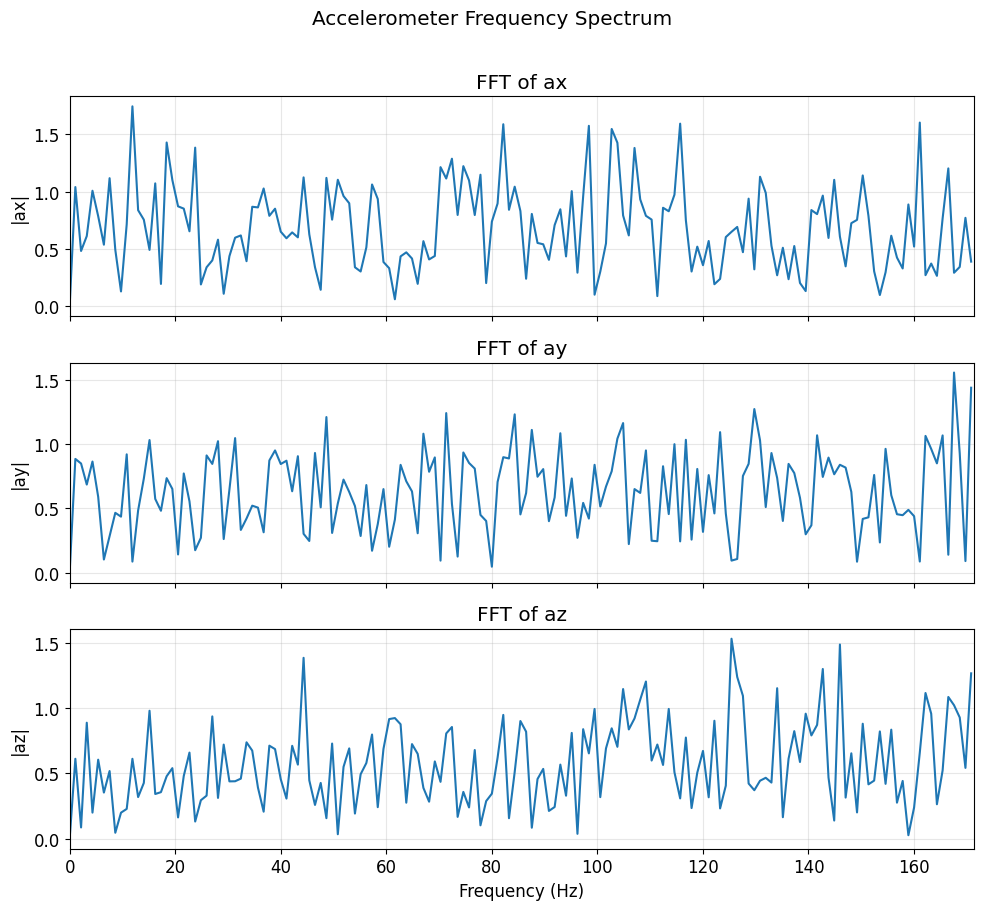

Sampling rate: 342.7 Hz


In [72]:
# Plot FFT of stationary accelerometer data
plot_accel_fft(df_stationary, save_path='fft_stationary.png')

In [73]:
# Collect vibration data
print("Place IMU on table, then TAP/VIBRATE the table during recording...")
print("Recording starts in 2 seconds...")
time.sleep(2)

df_vibration = collect_imu_data(duration_s=5)
print(f"Collected {len(df_vibration)} samples")

Place IMU on table, then TAP/VIBRATE the table during recording...
Recording starts in 2 seconds...
Recording for 5 seconds...
Transferring data via Bluetooth...
Waiting 11.0s for transfer (estimated 1500 samples)...
Collected 318 samples
Actual duration: 0.88 seconds
Collected 318 samples


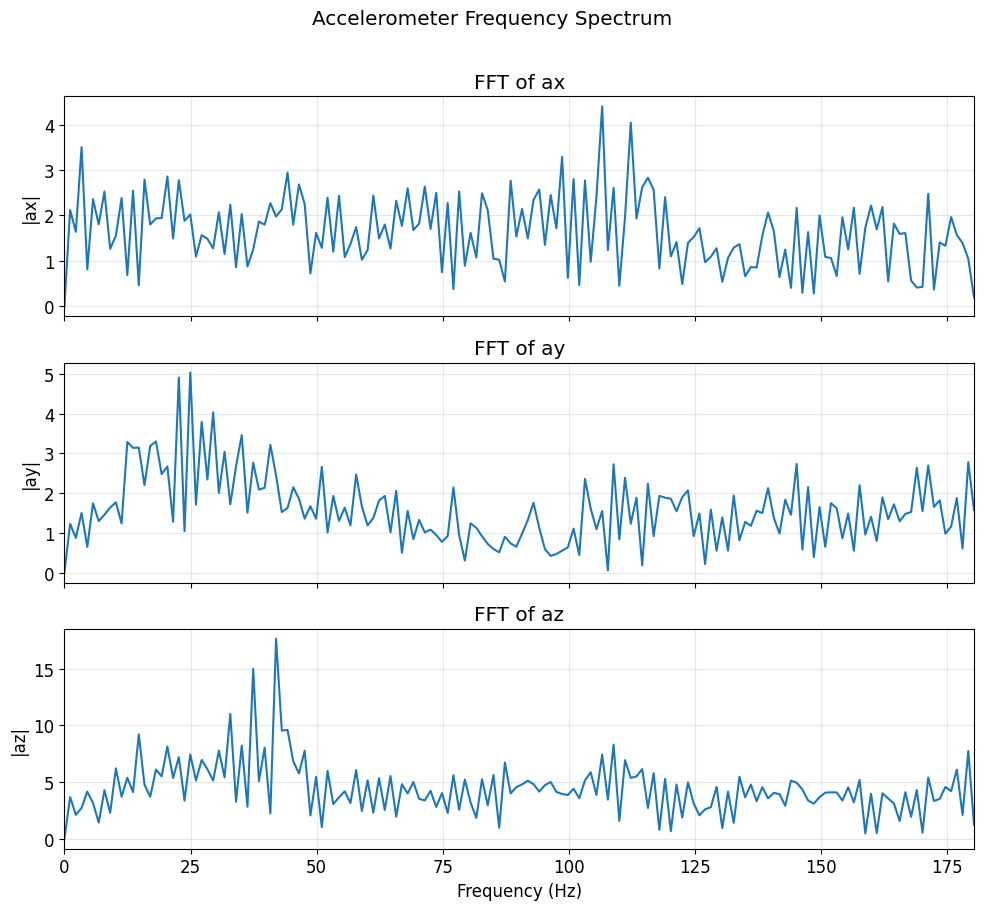

Sampling rate: 360.6 Hz


In [74]:
# Plot FFT of vibration data
plot_accel_fft(df_vibration, save_path='fft_vibration.png')

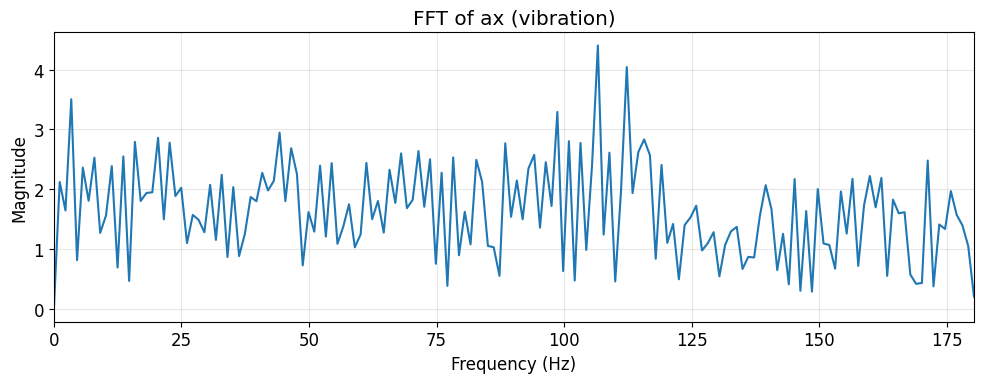

Sampling rate: 360.6 Hz, Nyquist frequency: 180.3 Hz


In [75]:
# Individual FFT for pitch (useful for cutoff frequency analysis)
freqs, mags = plot_fft(df_vibration, 'ax', title='FFT of ax (vibration)', save_path='fft_ax_vibration.png')

### Choosing a Low-Pass Filter Cutoff Frequency

Based on the FFT analysis above:
- Identify the highest frequency where you see meaningful signal
- Set the cutoff frequency to be slightly above that
- Typical values: 1-10 Hz for orientation, depending on application

The alpha for the low-pass filter is computed as:
```
alpha = dt / (dt + 1/(2*pi*fc))
```
where `fc` is the cutoff frequency and `dt` is the sample period.

In [76]:
# Calculate alpha for different cutoff frequencies
dt = np.mean(np.diff(df_stationary['time_s'].values))
print(f"Average sample period: {dt*1000:.2f} ms")
print(f"Sample rate: {1/dt:.1f} Hz")
print()

for fc in [1, 2, 5, 10, 20]:
    alpha = dt / (dt + 1/(2*np.pi*fc))
    print(f"Cutoff {fc:2d} Hz -> alpha = {alpha:.4f}")

Average sample period: 2.92 ms
Sample rate: 342.7 Hz

Cutoff  1 Hz -> alpha = 0.0180
Cutoff  2 Hz -> alpha = 0.0354
Cutoff  5 Hz -> alpha = 0.0840
Cutoff 10 Hz -> alpha = 0.1549
Cutoff 20 Hz -> alpha = 0.2683


---
# Task 3: Compare Raw vs LPF vs Gyro vs Complementary Filter

In [77]:
# Collect data while moving the IMU
print("Move the IMU slowly through pitch and roll motions...")
print("Recording starts in 2 seconds...")
time.sleep(2)

df_motion = collect_imu_data(duration_s=10)
print(f"Collected {len(df_motion)} samples")

Move the IMU slowly through pitch and roll motions...
Recording starts in 2 seconds...
Recording for 10 seconds...
Transferring data via Bluetooth...
Waiting 20.0s for transfer (estimated 3000 samples)...
Collected 533 samples
Actual duration: 1.45 seconds
Collected 533 samples


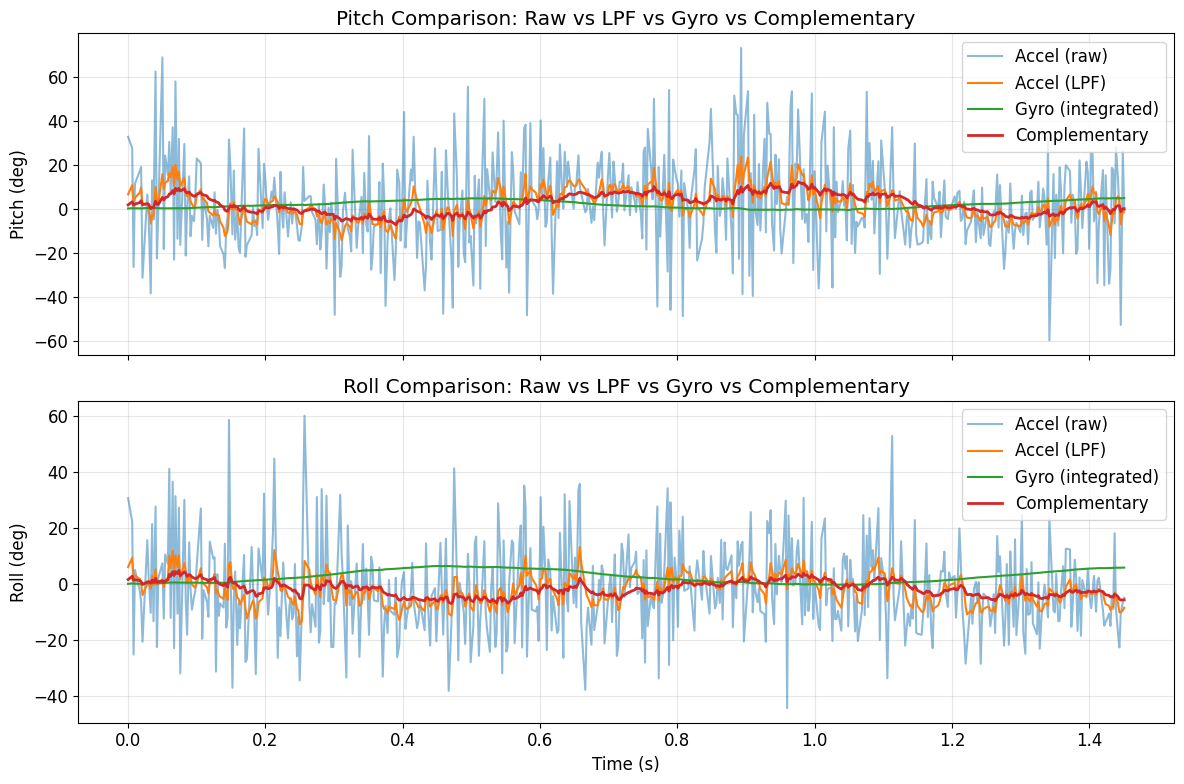

In [78]:
# Plot comparison of all filter methods
plot_pitch_roll_comparison(df_motion, save_path='filter_comparison.png')

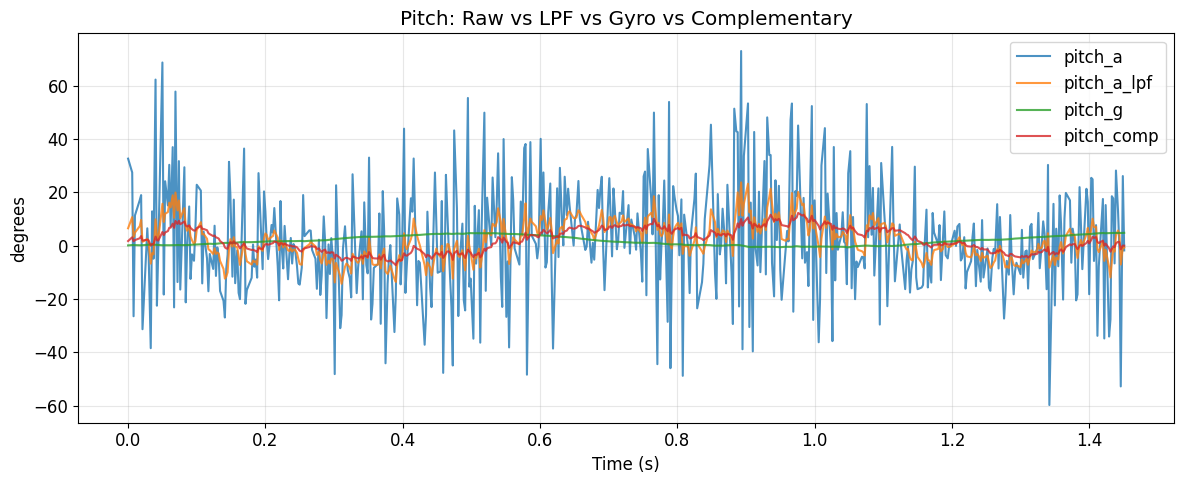

In [79]:
# Plot just pitch with all methods
plot_time_series(df_motion, 
                 ['pitch_a', 'pitch_a_lpf', 'pitch_g', 'pitch_comp'],
                 'Pitch: Raw vs LPF vs Gyro vs Complementary',
                 save_path='pitch_comparison.png')

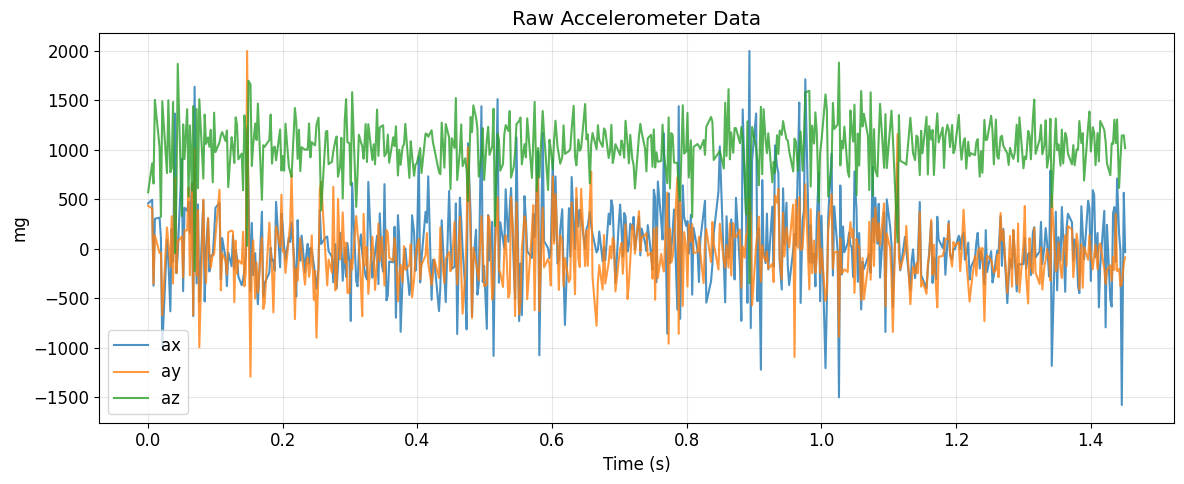

In [80]:
# Plot raw accelerometer data
plot_time_series(df_motion, ['ax', 'ay', 'az'], 
                 'Raw Accelerometer Data', ylabel='mg',
                 save_path='accel_raw.png')

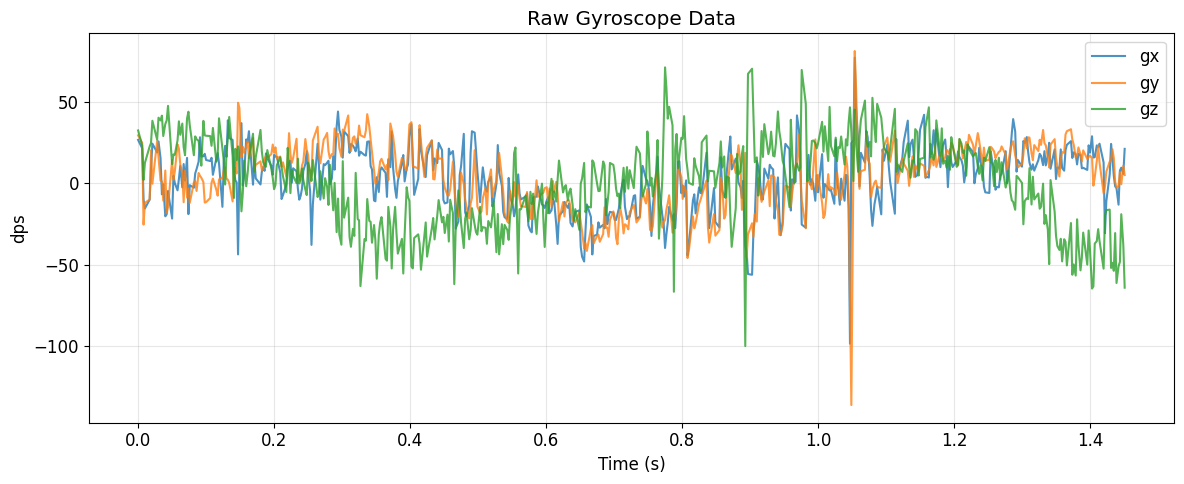

In [81]:
# Plot raw gyroscope data
plot_time_series(df_motion, ['gx', 'gy', 'gz'],
                 'Raw Gyroscope Data', ylabel='dps',
                 save_path='gyro_raw.png')

---
# Task 4: Demonstrate Complementary Filter Stability

Show that the complementary filter:
1. Is not susceptible to drift (unlike gyro integration)
2. Is not susceptible to quick vibrations (unlike accelerometer)

In [87]:
# Test for drift - hold IMU still for 10+ seconds
print("Hold IMU STILL for drift test (10 seconds)...")
df_drift = collect_imu_data(duration_s=10)
print(f"Collected {len(df_drift)} samples")

Hold IMU STILL for drift test (10 seconds)...
Recording for 10 seconds...
Transferring data via Bluetooth...
Waiting 20.0s for transfer (estimated 3000 samples)...
Collected 545 samples
Actual duration: 1.39 seconds
Collected 545 samples


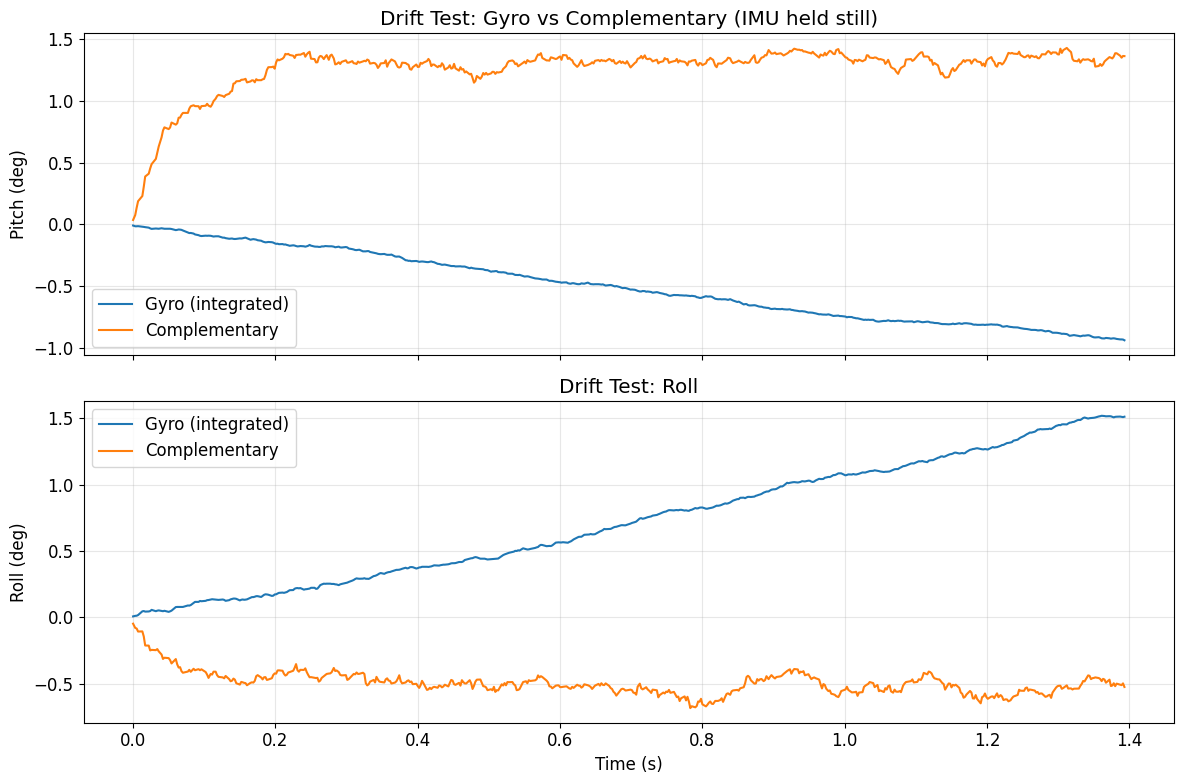

Gyro pitch drift: -0.93 deg
Comp pitch drift: 1.33 deg


In [88]:
# Compare gyro drift vs complementary stability
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_drift['time_s'], df_drift['pitch_g'], label='Gyro (integrated)')
axes[0].plot(df_drift['time_s'], df_drift['pitch_comp'], label='Complementary')
axes[0].set_ylabel('Pitch (deg)')
axes[0].set_title('Drift Test: Gyro vs Complementary (IMU held still)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_drift['time_s'], df_drift['roll_g'], label='Gyro (integrated)')
axes[1].plot(df_drift['time_s'], df_drift['roll_comp'], label='Complementary')
axes[1].set_ylabel('Roll (deg)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Drift Test: Roll')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('drift_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Gyro pitch drift: {df_drift['pitch_g'].iloc[-1] - df_drift['pitch_g'].iloc[0]:.2f} deg")
print(f"Comp pitch drift: {df_drift['pitch_comp'].iloc[-1] - df_drift['pitch_comp'].iloc[0]:.2f} deg")

In [90]:
# Test for vibration rejection - shake/tap while recording
print("TAP/VIBRATE the IMU during recording (5 seconds)...")
print("Recording starts in 2 seconds...")
time.sleep(2)

df_shake = collect_imu_data(duration_s=5)
print(f"Collected {len(df_shake)} samples")

TAP/VIBRATE the IMU during recording (5 seconds)...
Recording starts in 2 seconds...
Recording for 5 seconds...
Transferring data via Bluetooth...
Waiting 11.0s for transfer (estimated 1500 samples)...
Collected 315 samples
Actual duration: 0.89 seconds
Collected 315 samples


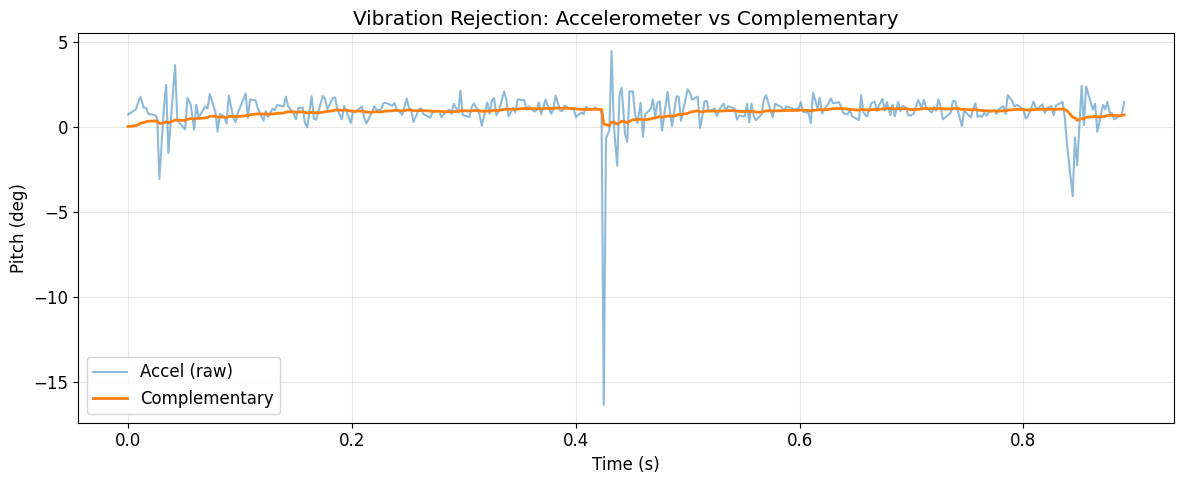

In [91]:
# Compare accelerometer noise vs complementary stability during vibration
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_shake['time_s'], df_shake['pitch_a'], alpha=0.5, label='Accel (raw)')
ax.plot(df_shake['time_s'], df_shake['pitch_comp'], linewidth=2, label='Complementary')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pitch (deg)')
ax.set_title('Vibration Rejection: Accelerometer vs Complementary')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vibration_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Task 5: Collect 5+ Seconds of IMU Data via Bluetooth

This demonstrates that your board can capture at least 5 seconds of IMU data and transmit it via BLE.

In [121]:
# Task 5: Collect 5+ seconds of IMU data
# Using compact format for reliable BLE transfer

print("Collecting 6 seconds of IMU data...")
print("You can move the IMU to show data capture...")

df_5sec = collect_imu_data(duration_s=6)

# Verify duration
if len(df_5sec) > 0:
    duration = df_5sec['time_s'].iloc[-1]
    sample_rate = len(df_5sec) / duration if duration > 0 else 0
    
    print(f"\n=== Task 5 Results ===")
    print(f"Total samples: {len(df_5sec)}")
    print(f"Duration: {duration:.2f} seconds")
    print(f"Sample rate: {sample_rate:.1f} Hz")
    
    if duration >= 5:
        print("✓ Successfully collected 5+ seconds of data!")
    else:
        print(f"⚠ Only got {duration:.2f}s - may need to increase transfer time")

You can move the IMU to show data capture...
Recording for 6 seconds...
Transferring data via Bluetooth...
Waiting 30.0s for transfer...
Collected 667 samples
Actual duration: 5.34 seconds

=== Task 5 Results ===
Total samples: 667
Duration: 5.34 seconds
Sample rate: 124.8 Hz
✓ Successfully collected 5+ seconds of data!


In [122]:
# Verify we have 5+ seconds of data
duration = df_5sec['time_s'].iloc[-1] - df_5sec['time_s'].iloc[0]
print(f"\n=== Data Collection Summary ===")
print(f"Total samples: {len(df_5sec)}")
print(f"Duration: {duration:.2f} seconds")
print(f"Sample rate: {len(df_5sec)/duration:.1f} Hz")
print(f"\nData successfully transmitted via Bluetooth!")


=== Data Collection Summary ===
Total samples: 667
Duration: 5.34 seconds
Sample rate: 124.8 Hz

Data successfully transmitted via Bluetooth!


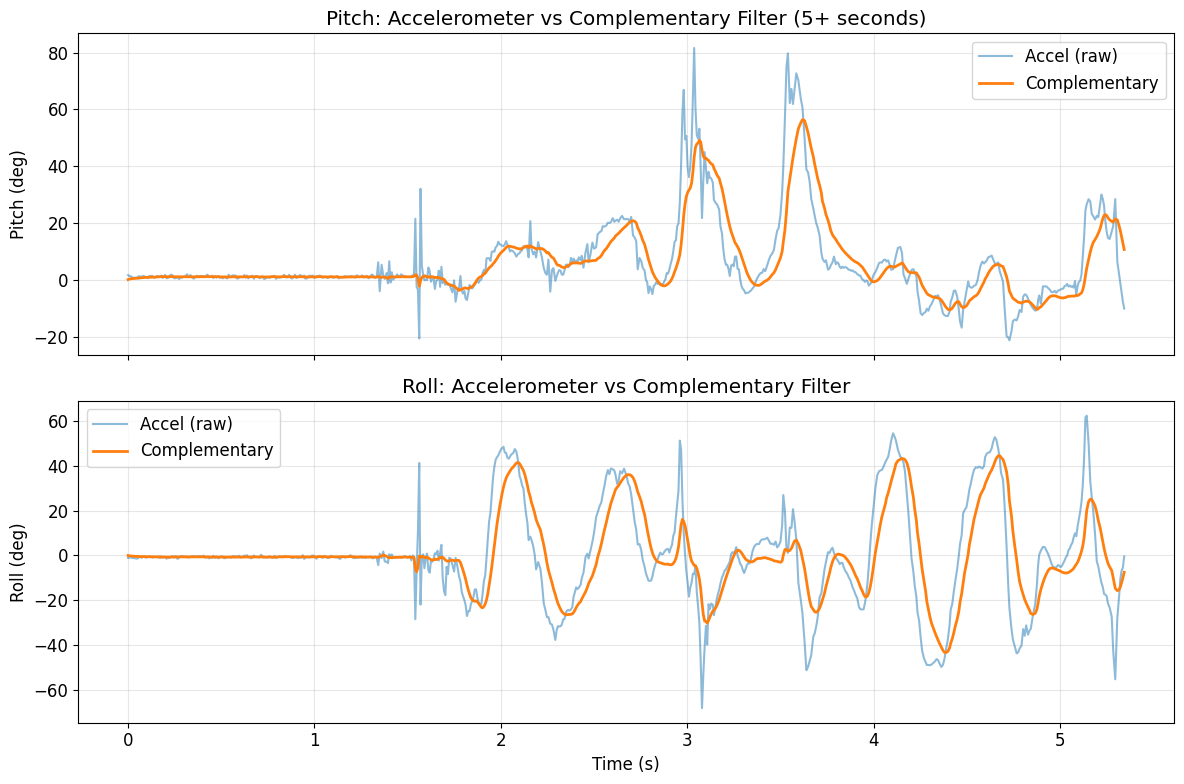


✓ Task 5 Complete: 5.34 seconds of IMU data transmitted via BLE


In [123]:
# Plot the 5+ second data (compact format: pitch_a, roll_a, pitch_comp, roll_comp)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Pitch
axes[0].plot(df_5sec['time_s'], df_5sec['pitch_a'], alpha=0.5, label='Accel (raw)')
axes[0].plot(df_5sec['time_s'], df_5sec['pitch_comp'], linewidth=2, label='Complementary')
axes[0].set_ylabel('Pitch (deg)')
axes[0].set_title('Pitch: Accelerometer vs Complementary Filter (5+ seconds)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Roll
axes[1].plot(df_5sec['time_s'], df_5sec['roll_a'], alpha=0.5, label='Accel (raw)')
axes[1].plot(df_5sec['time_s'], df_5sec['roll_comp'], linewidth=2, label='Complementary')
axes[1].set_ylabel('Roll (deg)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Roll: Accelerometer vs Complementary Filter')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('5sec_data.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Task 5 Complete: {df_5sec['time_s'].iloc[-1]:.2f} seconds of IMU data transmitted via BLE")

In [124]:
# Save data to CSV for the report
df_5sec.to_csv('imu_5sec_data.csv', index=False)
print("Data saved to imu_5sec_data.csv")

Data saved to imu_5sec_data.csv


---
# Optional: Adjust Filter Parameters

In [125]:
# You can adjust the filter parameters remotely
# alpha_lpf: Low-pass filter alpha (0.1-0.5 typical)
# alpha_comp: Complementary filter alpha (0.02-0.1 typical)

new_alpha_lpf = 0.1
new_alpha_comp = 0.02

ble.send_command(CMD.SET_IMU_PARAMS, f"{new_alpha_lpf}|{new_alpha_comp}")
time.sleep(0.1)
response = ble.receive_string(ble.uuid['RX_STRING'])
print(f"Response: {response}")

Response: PARAMS_SET|0.100|0.020


---
## Disconnect

In [ ]:
ble.disconnect()
print("Disconnected from Artemis")